In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

In [2]:
commerce = pd.read_csv('/content/ecommerce_returns_2000.csv')

In [3]:
commerce

,Customer_ID,Age,Gender,City,Product_Category,Product_Price,Quantity,Discount,Payment_Method,Order_Value,Previous_Orders,Customer_Rating,Delivery_Days,Return_Reason,Returned
0,CUST100001,39.0,Other,Thrissur,Electronics,1160.58,2,24.9,Debit Card,1743.19,7.0,5.0,1.0,No Return,0
1,CUST100002,33.0,Male,Delhi,Books,1638.61,1,3.0,Net Banking,1589.45,5.0,2.8,7.0,No Return,0
2,CUST100003,40.0,Male,Pune,Books,1075.42,5,20.1,Cash on Delivery,4296.30,5.0,4.6,2.0,No Return,0
3,CUST100004,49.0,Male,Mumbai,Beauty,1473.46,2,7.3,Credit Card,2731.79,5.0,4.4,6.0,No Return,0
4,CUST100005,32.0,Female,Mumbai,Fashion,525.68,2,23.0,Credit Card,809.55,6.0,3.4,3.0,No Return,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CUST101996,45.0,Female,Kozhikode,Books,1833.61,2,20.2,Net Banking,2926.44,4.0,4.7,2.0,No Return,0
1996,CUST101997,34.0,Female,Kozhikode,Fashion,466.36,1,1.2,Cash on Delivery,460.76,7.0,3.8,1.0,No Return,0
1997,CUST101998,25.0,Female,Hyderabad,Sports,1461.69,1,5.3,Credit Card,1384.22,4.0,NaN,7.0,No Return,0
1998,CUST101999,32.0,Female,Mumbai,Home & Kitchen,5238.22,1,35.5,UPI,3378.65,4.0,3.6,5.0,No Return,0


In [4]:
commerce.shape

(2000, 15)

In [5]:
commerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       2000 non-null   object 
 1   Age               1940 non-null   float64
 2   Gender            1960 non-null   object 
 3   City              1960 non-null   object 
 4   Product_Category  1960 non-null   object 
 5   Product_Price     1950 non-null   float64
 6   Quantity          2000 non-null   int64  
 7   Discount          1940 non-null   float64
 8   Payment_Method    1960 non-null   object 
 9   Order_Value       2000 non-null   float64
 10  Previous_Orders   1950 non-null   float64
 11  Customer_Rating   1920 non-null   float64
 12  Delivery_Days     1940 non-null   float64
 13  Return_Reason     1930 non-null   object 
 14  Returned          2000 non-null   int64  
dtypes: float64(7), int64(2), object(6)
memory usage: 234.5+ KB


In [6]:
commerce.duplicated().sum()

np.int64(0)

In [7]:
commerce.isnull().sum()

,0
Customer_ID,0
Age,60
Gender,40
City,40
Product_Category,40
Product_Price,50
Quantity,0
Discount,60
Payment_Method,40
Order_Value,0


#missing values handling

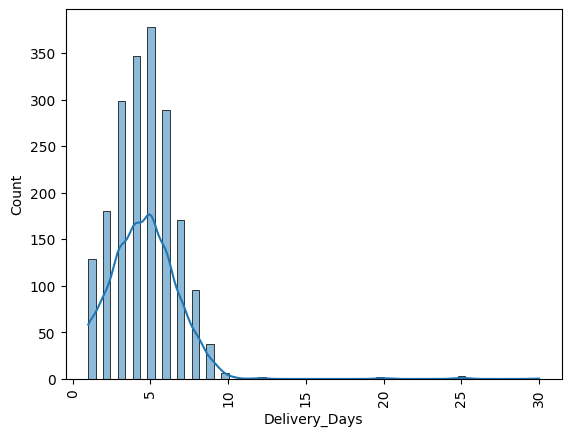

In [8]:
sns.histplot(commerce['Delivery_Days'],kde= True)
plt.xticks(rotation = 90)
plt.show()

In [9]:
commerce.dtypes

,0
Customer_ID,object
Age,float64
Gender,object
City,object
Product_Category,object
Product_Price,float64
Quantity,int64
Discount,float64
Payment_Method,object
Order_Value,float64


In [10]:
commerce.columns

Index(['Customer_ID', 'Age', 'Gender', 'City', 'Product_Category',
       'Product_Price', 'Quantity', 'Discount', 'Payment_Method',
       'Order_Value', 'Previous_Orders', 'Customer_Rating', 'Delivery_Days',
       'Return_Reason', 'Returned'],
      dtype='object')

In [11]:
commerce.isnull().sum()

,0
Customer_ID,0
Age,60
Gender,40
City,40
Product_Category,40
Product_Price,50
Quantity,0
Discount,60
Payment_Method,40
Order_Value,0


In [12]:
#drop unnecessary columns
commerce.drop('Customer_ID',axis = 1,inplace=True)
commerce.drop('Return_Reason',axis = 1,inplace=True)



In [13]:
commerce.isnull().sum()

,0
Age,60
Gender,40
City,40
Product_Category,40
Product_Price,50
Quantity,0
Discount,60
Payment_Method,40
Order_Value,0
Previous_Orders,50


In [14]:
#percentage of missing values
commerce.isna().sum()/len(commerce)*100

,0
Age,3.0
Gender,2.0
City,2.0
Product_Category,2.0
Product_Price,2.5
Quantity,0.0
Discount,3.0
Payment_Method,2.0
Order_Value,0.0
Previous_Orders,2.5


In [15]:
#fill missing values
commerce['Age'] = commerce['Age'].fillna(commerce['Age'].mean())

In [16]:
commerce['City'] = commerce['City'].fillna(commerce['City'].mode()[0])

In [17]:
commerce['Gender'] = commerce['Gender'].ffill()

In [18]:
commerce['Product_Category'] = commerce['Product_Category'].fillna(commerce['Product_Category'].mode()[0])

In [19]:
commerce['Product_Price'] = commerce['Product_Price'].fillna(commerce['Product_Price'].median())

In [20]:
commerce['Discount'] = commerce['Discount'].fillna(commerce['Discount'].median())

In [21]:
commerce['Payment_Method'] = commerce['Payment_Method'].fillna(commerce['Payment_Method'].mode()[0])

In [22]:
commerce['Previous_Orders'] = commerce['Previous_Orders'].fillna(commerce['Previous_Orders'].mean())

In [23]:
commerce['Customer_Rating'] = commerce['Customer_Rating'].fillna(commerce['Customer_Rating'].mean())

In [24]:
commerce['Delivery_Days'] = commerce['Delivery_Days'].fillna(commerce['Delivery_Days'].median())

In [25]:
commerce.isnull().sum()

,0
Age,0
Gender,0
City,0
Product_Category,0
Product_Price,0
Quantity,0
Discount,0
Payment_Method,0
Order_Value,0
Previous_Orders,0


#outlier

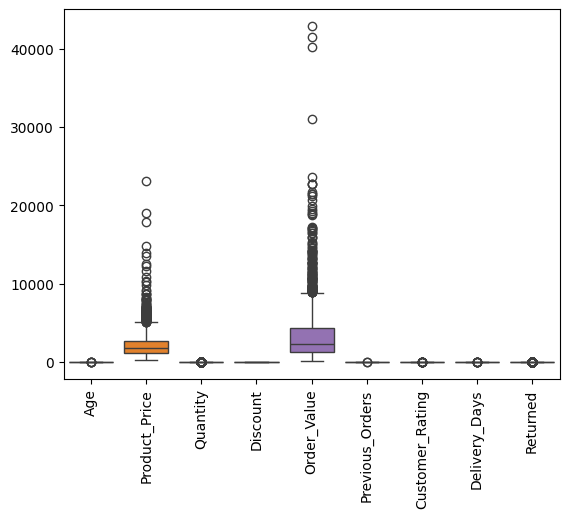

In [26]:
sns.boxplot(commerce)
plt.xticks(rotation = 90)
plt.show()

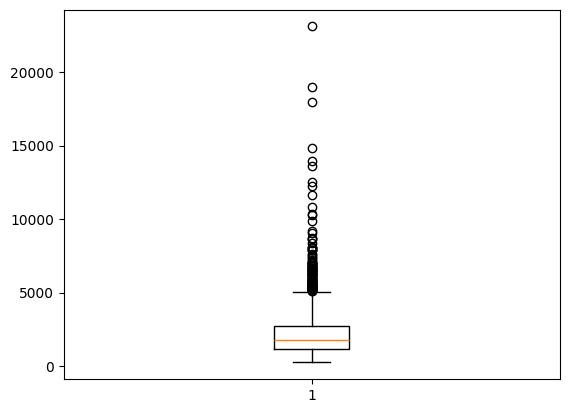

In [29]:
plt.boxplot(commerce['Product_Price'])
plt.show()

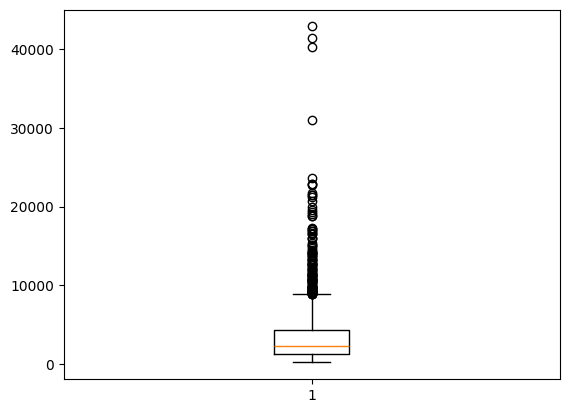

In [30]:
plt.boxplot(commerce['Order_Value'])
plt.show()

#outlier handling

#IQR method

In [31]:
q1 =commerce['Product_Price'].quantile(0.25)
q2 =commerce['Product_Price'].quantile(0.5)
q3 =commerce['Product_Price'].quantile(0.75)

print(f'Q1 ={q1}\nQ2 ={q2}\nQ3 ={q3}')
IQR = q3 -q1
up_lim = q3+(1.5*IQR)
low_lim = q1 -(1.5*IQR)
print(f'Iqr = {IQR} \n UPPER LIMIT = {up_lim} \n LOWER LIMIT = {low_lim}')

commerce.loc[commerce['Product_Price'] > up_lim, 'Product_Price'] = up_lim
commerce.loc[commerce['Product_Price'] < low_lim, 'Product_Price'] = low_lim
print(f'IQR={IQR}')

Q1 =1169.48
Q2 =1800.4299999999998
Q3 =2741.895
Iqr = 1572.415 
 UPPER LIMIT = 5100.5175 
 LOWER LIMIT = -1189.1425
IQR=1572.415


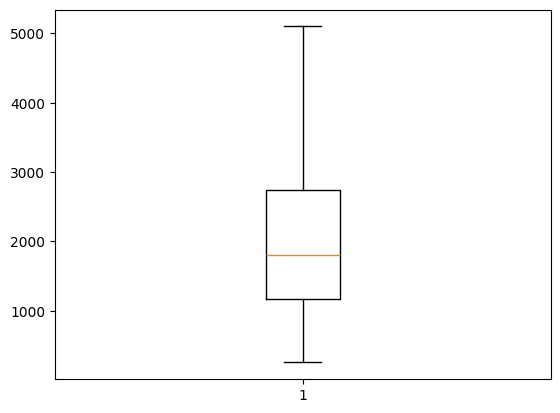

In [32]:
plt.boxplot(commerce['Product_Price'])
plt.show()

In [33]:
q1 =commerce['Order_Value'].quantile(0.25)
q2 =commerce['Order_Value'].quantile(0.5)
q3 =commerce['Order_Value'].quantile(0.75)

print(f'Q1 ={q1}\nQ2 ={q2}\nQ3 ={q3}')
IQR = q3 -q1
up_lim = q3+(1.5*IQR)
low_lim = q1 -(1.5*IQR)
print(f'Iqr = {IQR} \n UPPER LIMIT = {up_lim} \n LOWER LIMIT = {low_lim}')

commerce.loc[commerce['Order_Value'] > up_lim, 'Order_Value'] = up_lim
commerce.loc[commerce['Order_Value'] < low_lim, 'Order_Value'] = low_lim
print(f'IQR={IQR}')

Q1 =1239.71
Q2 =2305.285
Q3 =4296.1050000000005
Iqr = 3056.3950000000004 
 UPPER LIMIT = 8880.697500000002 
 LOWER LIMIT = -3344.8825000000006
IQR=3056.3950000000004


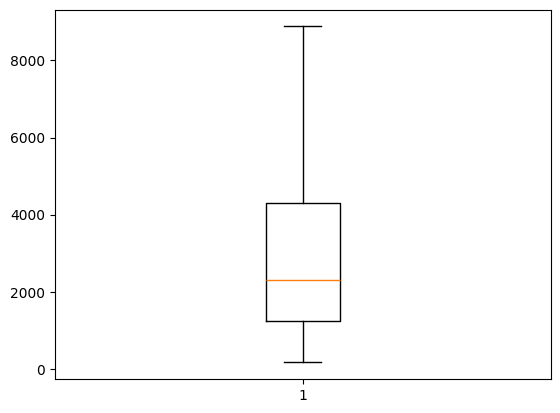

In [34]:
plt.boxplot(commerce['Order_Value'])
plt.show()

#ENCODING

In [35]:
commerce.select_dtypes(include=object).columns

Index(['Gender', 'City', 'Product_Category', 'Payment_Method'], dtype='object')

In [36]:
commerce['Gender'].unique()

array(['Other', 'Male', 'Female'], dtype=object)

In [37]:
commerce['City'].unique()

array(['Thrissur', 'Delhi', 'Pune', 'Mumbai', 'Hyderabad',
       'Thiruvananthapuram', 'Bengaluru', 'Kozhikode', 'Kochi', 'Chennai'],
      dtype=object)

In [38]:
commerce['Product_Category'].unique()

array(['Electronics', 'Books', 'Beauty', 'Fashion', 'Sports',
       'Home & Kitchen'], dtype=object)

In [39]:
commerce['Payment_Method'].unique()

array(['Debit Card', 'Net Banking', 'Cash on Delivery', 'Credit Card',
       'UPI'], dtype=object)

In [40]:
# apply onehot encoding

commerce = pd.get_dummies(commerce,dtype = 'int',drop_first=True)

In [41]:
commerce.dtypes

,0
Age,float64
Product_Price,float64
Quantity,int64
Discount,float64
Order_Value,float64
Previous_Orders,float64
Customer_Rating,float64
Delivery_Days,float64
Returned,int64
Gender_Male,int64


# separate feature and target column

In [42]:
y =commerce['Returned']
x =commerce.drop('Returned',axis=1)

In [43]:
## creating copy of feature

x1= x.copy()

In [44]:
y =commerce['Returned'].reset_index(drop=True)
x =commerce.drop('Returned',axis=1).reset_index(drop=True)

In [45]:
# scaled x_train1 and x_test1
from sklearn.model_selection import train_test_split
x_train1, x_test1, y_train, y_test = train_test_split(x1, y, test_size=0.2, random_state=42,)

In [46]:
# non scaled x_train and x_test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# scaling

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
for i in x1.columns:
  x1[i] = scaler.fit_transform(x1[[i]])

# logistic regression

In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

lr_model_scaled = LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=1000)
lr_model_scaled.fit(x_train1, y_train)

y_pred_lr_model_scaled = lr_model_scaled.predict(x_test1)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_model_scaled))
print('Accuracy is: ', accuracy_score(y_test, y_pred_lr_model_scaled))
print('Precision is: ', precision_score(y_test, y_pred_lr_model_scaled))
print('Recall is: ', recall_score(y_test, y_pred_lr_model_scaled))
print('F1 score is: ', f1_score(y_test, y_pred_lr_model_scaled))

Confusion Matrix:
[[220 144]
 [ 15  21]]
Accuracy is:  0.6025
Precision is:  0.12727272727272726
Recall is:  0.5833333333333334
F1 score is:  0.208955223880597


# Decision tree

In [50]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

dt_model_scaled = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

dt_model_scaled.fit(x_train, y_train)

y_pred_dt_model_scaled = dt_model_scaled.predict(x_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_model_scaled))

print('Accuracy is: ', accuracy_score(y_test, y_pred_dt_model_scaled))

print('Precision is: ', precision_score(y_test, y_pred_dt_model_scaled))

print('Recall is: ', recall_score(y_test, y_pred_dt_model_scaled))

print('f score is: ', f1_score(y_test, y_pred_dt_model_scaled))

Confusion Matrix:
[[326  38]
 [ 32   4]]
Accuracy is:  0.825
Precision is:  0.09523809523809523
Recall is:  0.1111111111111111
f score is:  0.10256410256410256


#random forest

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_rf, zero_division=0))

Confusion Matrix:
[[362   2]
 [ 36   0]]
Accuracy: 0.905
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


#KNN

In [52]:

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

knn_model_scaled = KNeighborsClassifier(n_neighbors=5)

knn_model_scaled.fit(x_train1, y_train)

y_pred_knn_model_scaled = knn_model_scaled.predict(x_test1)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn_model_scaled))

print('Accuracy is: ', accuracy_score(y_test, y_pred_knn_model_scaled))

print('Precision is: ', precision_score(y_test, y_pred_knn_model_scaled))

print('Recall is: ', recall_score(y_test, y_pred_knn_model_scaled))

print('F1 score is: ', f1_score(y_test, y_pred_knn_model_scaled))

Confusion Matrix:
[[356   8]
 [ 35   1]]
Accuracy is:  0.8925
Precision is:  0.1111111111111111
Recall is:  0.027777777777777776
F1 score is:  0.044444444444444446


#SVM

In [53]:
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

svm_model_scaled = SVC(
    class_weight='balanced',
    random_state=42
)

svm_model_scaled.fit(x_train1, y_train)

y_pred_svm_model_scaled = svm_model_scaled.predict(x_test1)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm_model_scaled))

print('Accuracy is: ', accuracy_score(y_test, y_pred_svm_model_scaled))

print('Precision is: ', precision_score(y_test, y_pred_svm_model_scaled))

print('Recall is: ', recall_score(y_test, y_pred_svm_model_scaled))

print('F1 score is: ', f1_score(y_test, y_pred_svm_model_scaled))

Confusion Matrix:
[[136 228]
 [ 10  26]]
Accuracy is:  0.405
Precision is:  0.10236220472440945
Recall is:  0.7222222222222222
F1 score is:  0.1793103448275862



#Among the evaluated classification models, Logistic Regression performed best overall based on the F1-score. Although SVM achieved the highest recall, Logistic Regression provided a better balance between precision and recall. Random Forest achieved the highest accuracy, but its recall and F1-score were zero because it failed to identify any positive cases. Therefore, Logistic Regression was selected as the best overall model.